# Checkpoint 4 — Regressão Linear e Polinomial

## Preço de carros usados no mercado espanhol

**Data Science & Statistical Computing — FIAP 2026**
Prof. Jones Egydio

### Integrantes do grupo

| Nome | RM |
|---|---|
| Leonardo Eiji Kina | 562784 |
| Nicholas Braga de Souza | 561733 |
| Tomé Rossi Giani | 562422 |
| Vitor Ramos de Farias | 561958 |

---

**Base:** *Coches de segunda mano Milanuncios* — Zenodo, DOI 10.5281/zenodo.4674757
**Licença:** CC BY-NC-SA 4.0
**Coleta:** anúncios de milanuncios.com, 09/04/2021
**Unidade de observação:** um anúncio de veículo

---
# 1. Proposição do problema

## 1.1 Pergunta de pesquisa

> **Em que medida a idade, a quilometragem, a potência e o tipo de câmbio
> explicam o preço anunciado de um carro usado no mercado espanhol, e a
> relação entre idade e preço é linear?**

A segunda parte não é decorativa: se a depreciação for mais intensa nos
primeiros anos, um modelo linear em idade será sistematicamente enviesado, e a
comparação com um modelo polinomial passa a ter motivação empírica.

## 1.2 Variável resposta

| | |
|---|---|
| Variável | `precio` |
| Tipo | Numérica contínua |
| Unidade | Euros (€) |
| Definição | Preço **pedido** no anúncio — não é preço de transação |

## 1.3 Dicionário de dados

| Variável | Tipo | Unidade / categorias | Descrição |
|---|---|---|---|
| `precio` | Numérica contínua | € | Preço pedido no anúncio |
| `ano_vehic` | Numérica discreta | ano | Ano de matrícula |
| `idade` | Numérica discreta | anos | Derivada: ano de referência − `ano_vehic` |
| `km` | Numérica contínua | quilômetros | Quilometragem acumulada |
| `cv` | Numérica contínua | cavalos de vapor | Potência |
| `puertas` | Numérica discreta | 2, 3, 4, 5 | Número de portas |
| `transmision` | Categórica nominal | manual / automático | Tipo de câmbio |
| `combustible` | Categórica nominal | diesel / gasolina / híbrido | Combustível |
| `marca` | Categórica nominal | 34 categorias | Marca do veículo |
| `ubicacion` | Categórica nominal | províncias | Localização (não utilizada) |
| `particular` | Categórica nominal | particular / profissional | Tipo de anunciante |

## 1.4 Hipóteses iniciais

Registradas **antes** da modelagem e retomadas na conclusão.

- **H1** — A relação entre idade e preço é decrescente e **convexa**.
- **H2** — `cv` será o preditor isolado mais forte.
- **H3** — `km` e `idade` são fortemente correlacionadas, gerando colinearidade problemática.
- **H4** — Câmbio automático associa-se a preço maior, mas parte do efeito é confundimento.
- **H5** — Veículos muito antigos não seguem a curva de depreciação.

## 1.5 Ressalva metodológica

Todas as relações investigadas são **associações observadas em anúncios**.
Desenho transversal, sem atribuição aleatória e com variáveis omitidas.
Nenhuma conclusão causal será afirmada.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
AZUL, LARANJA, CINZA = "#2c6fbb", "#e07b39", "#7a7a7a"

RANDOM_STATE = 42
TEST_SIZE = 0.30

---
# 2. Carregamento e primeira inspeção

O arquivo é lido **inteiramente como texto**. Isso é deliberado: a inferência
automática de tipos do pandas interpretaria `'3.900'` como o número 3,9 —
o ponto é separador de milhar no formato espanhol.

In [2]:
bruto = pd.read_csv("dados/coches.csv", dtype=str)
print("dimensões originais:", bruto.shape)
bruto.head(3)

dimensões originais: (500, 21)


,url,titulo,referencia,marca,modelo,ano_vehic,km,combustible,puertas,cv,...,ubicacion,vendedor,precio,particular,stats_visto,stats_contactado,stats_compartido,stats_favorito,stats_renovados,descripcion
0,https://www.milanuncios.com/seat-de-segunda-ma...,SEAT - LEON 1. 9 TDI 150CV SPORT FORMULA RACING,386492547,SEAT,LEON 1. 9 TDI 150CV SPORT FORMULA RACING,2004,241.665,diesel,5,150,...,ALICANTE,Eurocar,3.900,Profesional,7212,2,2,8,0,Precio contado: 3950 € modelo fr edicion limit...
1,https://www.milanuncios.com/audi-de-segunda-ma...,AUDI - A6,389541137,AUDI,A6,2005,188.212,diesel,5,140,...,ALMERíA,iulica,5.700,Particular,22604,0,2,11,0,Vendo audi A6 2005 2. 0 140 cp El coche esta e...
2,https://www.milanuncios.com/mercedes-benz-de-s...,MERCEDES-BENZ - CLASE E E 220 D,394413954,MERCEDES-BENZ,CLASE E E 220 D,2017,114.000,diesel,4,194,...,ASTURIAS,Urones Motor,33.900,Profesional,2786,0,0,0,0,Nacional# un solo propietario# procedente de c...


In [3]:
# A armadilha da conversão ingênua
ingenuo = pd.to_numeric(bruto["precio"], errors="coerce")
correto = pd.to_numeric(bruto["precio"].str.replace(".", "", regex=False), errors="coerce")

print(f"Conversão ingênua  -> preço mediano: {ingenuo.median():>10,.2f} €")
print(f"Conversão correta  -> preço mediano: {correto.median():>10,.2f} €")

Conversão ingênua  -> preço mediano:      12.50 €
Conversão correta  -> preço mediano:  12,495.00 €


A diferença é de três ordens de grandeza. Um carro de 12.495 € viraria 12,50 €.
Este é o primeiro problema de *data wrangling* identificado.

In [4]:
print("Valores ausentes por coluna:")
n = bruto.isna().sum()
print(n[n > 0].to_string())

print("\nCategorias de combustível encontradas:")
print(bruto["combustible"].value_counts().to_string())

Valores ausentes por coluna:
ano_vehic       2
km             17
puertas         2
cv              2
transmision     1

Categorias de combustível encontradas:
combustible
diesel      273
gasolina    170
híbrido      57


**Divergência com a documentação.** O registro no Zenodo declara que
`combustible` assume apenas `gasolina` e `diesel`. A base contém **57 registros
`híbrido`**. A documentação da fonte está incompleta; os três níveis são
mantidos.

In [5]:
# Os valores ausentes de km são aleatórios?
ano = pd.to_numeric(bruto["ano_vehic"], errors="coerce")
km  = pd.to_numeric(bruto["km"].str.replace(".", "", regex=False), errors="coerce")

print(f"Ano médio quando km está AUSENTE : {ano[km.isna()].mean():.1f}")
print(f"Ano médio quando km está PRESENTE: {ano[km.notna()].mean():.1f}")
print("\nDistribuição do ano quando km está ausente:")
print(ano[km.isna()].value_counts().sort_index().to_string())

Ano médio quando km está AUSENTE : 2020.6
Ano médio quando km está PRESENTE: 2014.1

Distribuição do ano quando km está ausente:
ano_vehic
2020.0    7
2021.0    9


**Achado importante.** Os 17 ausentes de `km` concentram-se integralmente em
veículos de 2020 e 2021. Não são dados perdidos: são **veículos zero-quilômetro**,
em que o anunciante não declara quilometragem. A ausência é *informativa*.

Imputar pela mediana global (85.000 km) atribuiria a um carro novo o uso de um
veículo de sete anos.

In [6]:
# Duplicatas de conteúdo: mesmo veículo, anúncios distintos
chave = ["marca", "modelo", "ano_vehic", "km", "precio", "cv"]
g = bruto.groupby(chave, dropna=False).size()
print("Grupos de veículos repetidos:")
print(g[g > 1].sort_values(ascending=False).to_string())

Grupos de veículos repetidos:
marca    modelo                                   ano_vehic  km       precio  cv 
OPEL     CROSSLAND X                              2020       10       15.490  110    6
         ASTRA 1. 2T SHL 81KW 110CV GS LINE ST    2020       10       14.990  110    4
         ASTRA 1. 5D DVH 90KW 122CV GS LINE       2021       10       16.490  122    4
BMW      COMPACT 320TD COMPACT                    2004       350.000  2.498   150    2
FORD     KUGA 1. 6 ECOBOOST 150 ASS 4X2 TITANIUM  2015       128.733  12.000  150    2
PEUGEOT  5008 1. 5 BLUEHDI 96KW 130CV SS ALLURE   2021       NaN      31.300  130    2


Um Opel Crossland X 2020 aparece **seis vezes**, idêntico. Não é erro de coleta:
é concessionária anunciando várias unidades do mesmo modelo em estoque.

Mantê-las daria peso seis vezes maior a esse veículo no ajuste e violaria a
independência das observações.

---
# 3. Data wrangling

## Princípio metodológico

Esta etapa executa **apenas limpeza determinística** — operações cujo resultado
não depende de nenhuma estatística estimada a partir dos dados.

Transformações **aprendidas** (imputação por mediana, padronização, one-hot,
expansão polinomial) ficam no `Pipeline`, ajustado somente no treino. Aplicá-las
aqui contaminaria o conjunto de teste.

In [7]:
from wrangling import limpar

d, registro, n_inicial = limpar("dados/coches.csv")
registro

,Problema,Decisão,Obs. afetadas
0,Veículos repetidos (mesmo modelo/ano/km/preço/...,Mantida a primeira ocorrência de cada veículo,14
1,precio e km armazenados como texto com ponto d...,Removido o separador e convertido para numérico,500
2,Data de referência ambígua na documentação da ...,"Adotado 2021, evidenciado por veículos ano 202...",16
3,Categorias com espaços e caixa inconsistentes;...,Padronizadas caixa e espaços; 'automat' renome...,486
4,km ausente concentrado em veículos 2020/2021 (...,Imputado km = 0 para veículos com idade <= 1 ano,15
5,Idade negativa (ano do veículo posterior à ref...,Registros removidos,0
6,precio ou idade ausentes,Removidos: imputar a variável resposta não é a...,2
7,19 marcas com menos de 10 anúncios,Agrupadas na categoria 'OUTRAS' (15 categorias...,57
8,Veículos com mais de 20 anos e preço acima da ...,SINALIZADOS para análise (não removidos): exce...,6
9,Colunas sem papel causal ou identificadores,Removidas (ver justificativa na proposição do ...,11


In [8]:
print(f"Base original : {n_inicial} linhas")
print(f"Base tratada  : {len(d)} linhas ({100*len(d)/n_inicial:.1f}% do original)")
print(f"Colunas       : {d.shape[1]}")
print("\nAusentes restantes (serão tratados no Pipeline):")
f = d.isna().sum()
print(f[f > 0].to_string() if f.sum() else "  nenhum")

Base original : 500 linhas
Base tratada  : 484 linhas (96.8% do original)
Colunas       : 14

Ausentes restantes (serão tratados no Pipeline):
puertas    1
cv         1


### Decisões que merecem destaque

**Ano de referência = 2021.** A descrição no Zenodo informa extração em
09/04/2020, mas o arquivo se chama `_09_04_2021` e a publicação é de abril de
2021. A base contém 16 veículos de ano 2021, impossíveis sob extração em 2020.

**Discrepantes sinalizados, não removidos.** Veículos com mais de 20 anos têm
preço mediano *acima* dos de 14 a 20 anos — comportamento de colecionador, não
erro. Ficam marcados em `possivel_classico`; a decisão sobre o domínio do
modelo é tomada na modelagem, com justificativa própria.

---
# 4. Análise exploratória

## 4.1 Estatísticas descritivas da variável resposta

In [9]:
print(d["precio"].describe().round(0).to_string())
print(f"\nassimetria: {d['precio'].skew():.2f}")
print(f"curtose   : {d['precio'].kurtosis():.2f}")
print(f"assimetria de log(precio): {np.log(d['precio']).skew():.2f}")

count      484.0
mean     14684.0
std      10539.0
min       1250.0
25%       7490.0
50%      12200.0
75%      18500.0
max      89999.0

assimetria: 2.28
curtose   : 9.01
assimetria de log(precio): -0.15


## 4.2 Figura 1 — Distribuição do preço

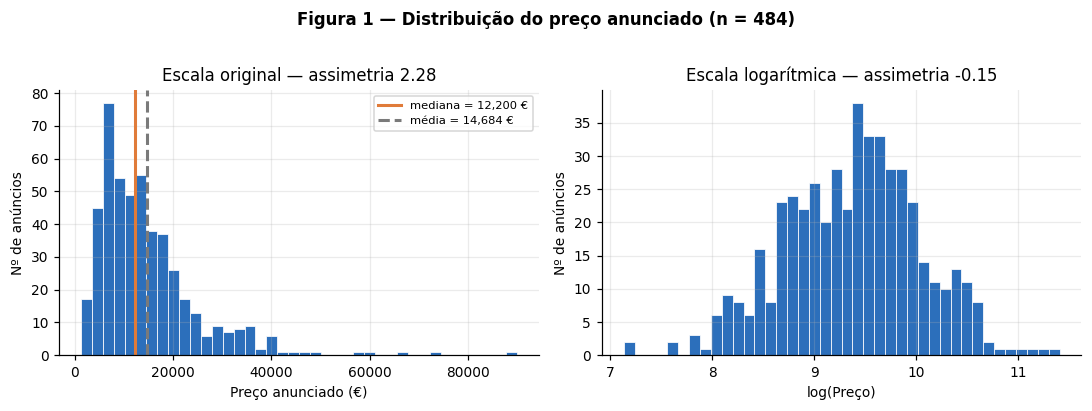

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))

ax[0].hist(d.precio, bins=40, color=AZUL, edgecolor="white", linewidth=0.5)
ax[0].axvline(d.precio.median(), color=LARANJA, lw=2, label=f"mediana = {d.precio.median():,.0f} €")
ax[0].axvline(d.precio.mean(), color=CINZA, lw=2, ls="--", label=f"média = {d.precio.mean():,.0f} €")
ax[0].set_xlabel("Preço anunciado (€)"); ax[0].set_ylabel("Nº de anúncios")
ax[0].set_title(f"Escala original — assimetria {d.precio.skew():.2f}")
ax[0].legend(fontsize=7.5)

ax[1].hist(np.log(d.precio), bins=40, color=AZUL, edgecolor="white", linewidth=0.5)
ax[1].set_xlabel("log(Preço)"); ax[1].set_ylabel("Nº de anúncios")
ax[1].set_title(f"Escala logarítmica — assimetria {np.log(d.precio).skew():.2f}")

fig.suptitle(f"Figura 1 — Distribuição do preço anunciado (n = {len(d)})", fontweight="bold", y=1.02)
fig.tight_layout(); plt.show()

**Interpretação.** Assimetria de 2,28 na escala original: a maioria concentra-se
entre 5.000 € e 20.000 €, com cauda até 90.000 €. Em log, a assimetria cai para
−0,15 e a distribuição fica praticamente simétrica.

A regressão linear não exige normalidade da resposta, mas exige resíduos
homoscedásticos. Uma resposta assim assimétrica costuma produzir erro absoluto
crescente com o nível de preço. **A transformação logarítmica será testada na
modelagem** — e o resultado é surpreendente.

## 4.3 Figura 2 — Preço por idade: o teste de H1

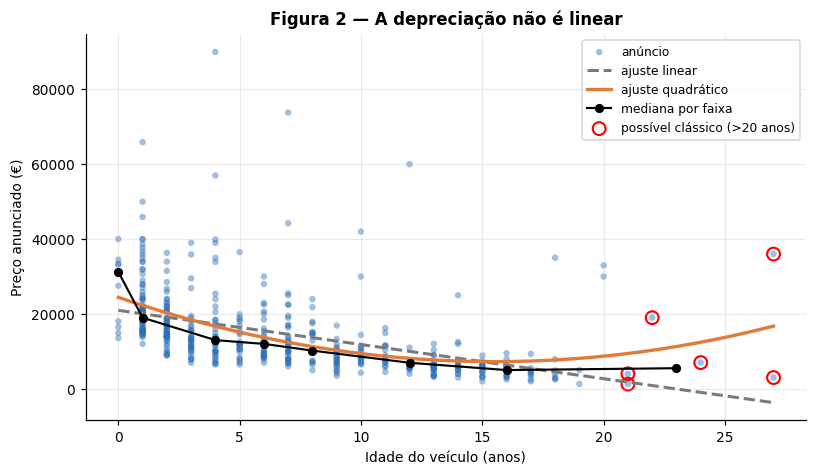

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.scatter(d.idade, d.precio, s=18, alpha=0.45, color=AZUL, edgecolors="none", label="anúncio")

x = np.linspace(d.idade.min(), d.idade.max(), 200)
ax.plot(x, np.polyval(np.polyfit(d.idade, d.precio, 1), x), color=CINZA, lw=2, ls="--", label="ajuste linear")
ax.plot(x, np.polyval(np.polyfit(d.idade, d.precio, 2), x), color=LARANJA, lw=2.2, label="ajuste quadrático")

faixas = pd.cut(d.idade, [-0.5, 0.5, 2, 4, 6, 9, 13, 20, 30])
med = d.groupby(faixas, observed=True).agg(idade=("idade", "median"), precio=("precio", "median"))
ax.plot(med.idade, med.precio, "o-", color="black", ms=5, lw=1.4, label="mediana por faixa")

cl = d[d.possivel_classico == 1]
ax.scatter(cl.idade, cl.precio, s=70, facecolors="none", edgecolors="red",
           linewidths=1.4, label="possível clássico (>20 anos)")

ax.set_xlabel("Idade do veículo (anos)"); ax.set_ylabel("Preço anunciado (€)")
ax.set_title("Figura 2 — A depreciação não é linear", fontweight="bold")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

In [12]:
p = d.precio.corr(d.idade)
s = d.precio.corr(d.idade, method="spearman")
print(f"Pearson (idade x preço) : {p:.3f}   <- capta relação LINEAR")
print(f"Spearman (idade x preço): {s:.3f}   <- capta relação MONÓTONA de qualquer forma")
print(f"\nDiferença: {abs(s) - abs(p):.3f}")

Pearson (idade x preço) : -0.471   <- capta relação LINEAR
Spearman (idade x preço): -0.712   <- capta relação MONÓTONA de qualquer forma

Diferença: 0.241


**H1 confirmada.** A queda é acentuada nos primeiros anos e achata a partir dos
dez. O contraste entre Pearson (−0,471) e Spearman (−0,712) é a evidência
numérica: a associação é forte e ordenada, mas Pearson a subestima porque a
relação não tem forma de reta.

**Achado adicional — os dois ajustes falham nos extremos, em direções opostas:**

- O **ajuste linear** cruza zero por volta dos 22 anos e passa a prever **preços
  negativos**, impossíveis por definição.
- O **ajuste quadrático** atinge mínimo aos ~17 anos e **volta a subir**,
  chegando a ~17.000 € aos 27 anos, contra mediana observada de ~5.000 €.

A causa da inversão são os seis clássicos (círculos vermelhos), pontos de alta
alavancagem sobre o termo quadrático.

**Consequência.** A comparação entre linear e polinomial não pode ser decidida
apenas por métricas globais.

## 4.4 Figura 3 — Correlações

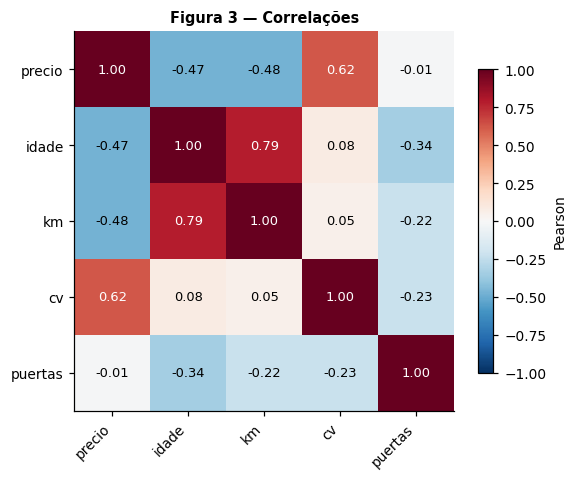

In [13]:
quant = ["precio", "idade", "km", "cv", "puertas"]
corr = d[quant].corr()

fig, ax = plt.subplots(figsize=(5.4, 4.4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(quant))); ax.set_xticklabels(quant, rotation=45, ha="right")
ax.set_yticks(range(len(quant))); ax.set_yticklabels(quant)
for i in range(len(quant)):
    for j in range(len(quant)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if abs(v) > 0.55 else "black")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson")
ax.set_title("Figura 3 — Correlações", fontweight="bold", fontsize=9.5)
fig.tight_layout(); plt.show()

**Interpretação.**

1. **`cv` é o preditor isolado mais forte** (r = 0,617) — **H2 confirmada**.
2. **`idade` e `km` correlacionam a 0,786 entre si** — informação redundante,
   a ser verificada por VIF (H3).
3. **`puertas` praticamente não se correlaciona com o preço** (r = −0,014).

`cv` é quase ortogonal a `idade` (0,078) e `km` (0,048): acrescenta informação
independente.

## 4.5 Figura 4 — Transmissão e o risco de confundimento

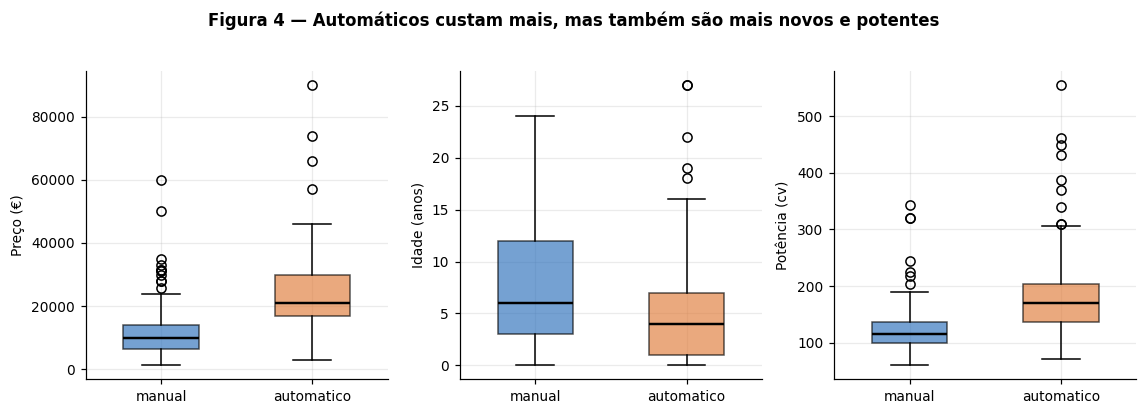

precio : manual =     9,990  |  automático =    20,990
idade  : manual =         6  |  automático =         4
cv     : manual =       115  |  automático =       170
km     : manual =   104,000  |  automático =    56,000


In [14]:
fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.6))
grupos = ["manual", "automatico"]
for i, (var, rot) in enumerate([("precio", "Preço (€)"), ("idade", "Idade (anos)"), ("cv", "Potência (cv)")]):
    dd = [d[d.transmision == g][var].dropna() for g in grupos]
    bp = ax[i].boxplot(dd, tick_labels=grupos, patch_artist=True, widths=0.5)
    for b, c in zip(bp["boxes"], [AZUL, LARANJA]):
        b.set_facecolor(c); b.set_alpha(0.65)
    for m in bp["medians"]:
        m.set_color("black"); m.set_linewidth(1.6)
    ax[i].set_ylabel(rot)
fig.suptitle("Figura 4 — Automáticos custam mais, mas também são mais novos e potentes",
             fontweight="bold", y=1.03)
fig.tight_layout(); plt.show()

for c in ["precio", "idade", "cv", "km"]:
    m = d[d.transmision == "manual"][c].median()
    a = d[d.transmision == "automatico"][c].median()
    print(f"{c:7s}: manual = {m:>9,.0f}  |  automático = {a:>9,.0f}")

**Interpretação.** Diferença bruta de mais de 11.000 €. Mas os automáticos
também são mais novos (4 vs 6 anos), mais potentes (170 vs 115 cv) e menos
rodados (56.000 vs 104.000 km).

**Esta é a justificativa central para a regressão múltipla:** o coeficiente com
as demais variáveis constantes deve ser bem menor que a diferença bruta.

---
# 5. Preparação para a modelagem

## Controle de vazamento de dados

Toda transformação aprendida está dentro de `Pipeline` + `ColumnTransformer`,
ajustada com `.fit()` **somente em `X_train`**. O teste passa apenas por
`.transform()`.

Consequência concreta: a mediana usada para imputar `cv` é a mediana **do
treino**. Calculá-la antes do split contaminaria o pré-processamento com
informação do teste e produziria métricas otimistas.

In [15]:
from sklearn.model_selection import train_test_split
from modelagem import construir, NUM, CAT

print("Variáveis quantitativas:", NUM)
print("Variáveis categóricas  :", CAT)

print("\nDescartadas e por quê:")
print("  particular  -> 497 profissionais vs 3 particulares: sem variação útil")
print("  url, referencia, titulo, vendedor -> identificadores")
print("  descripcion -> texto livre, fora do escopo")
print("  modelo      -> alta cardinalidade; segmento já captado por marca e cv")
print("  stats_*     -> CONSEQUÊNCIA do anúncio existir, não causa do preço")

Variáveis quantitativas: ['idade', 'km', 'cv', 'puertas']
Variáveis categóricas  : ['transmision', 'combustible', 'marca_agrupada']

Descartadas e por quê:
  particular  -> 497 profissionais vs 3 particulares: sem variação útil
  url, referencia, titulo, vendedor -> identificadores
  descripcion -> texto livre, fora do escopo
  modelo      -> alta cardinalidade; segmento já captado por marca e cv
  stats_*     -> CONSEQUÊNCIA do anúncio existir, não causa do preço


### O descarte das `stats_*` é uma decisão causal, não de conveniência

Número de visualizações, contatos e favoritos correlaciona-se com o preço, mas
é *consequência* de o anúncio estar publicado — e do próprio preço. Incluí-las
produziria um modelo com bom ajuste e **nenhuma utilidade preditiva** para um
carro ainda não anunciado.

---
# 6. Modelagem

Quatro modelos, conforme o enunciado.

| # | Modelo | Especificação | Justificativa |
|---|---|---|---|
| 1 | Referência | Média da resposta | Piso de comparação |
| 2 | Linear simples | `precio ~ cv` | Maior correlação **linear** (0,617) |
| 3 | Linear múltipla | Todas as variáveis relevantes | — |
| 4 | Polinomial | Grau 2 apenas em `idade` | Não linearidade documentada |

**Por que `cv` e não `idade` no modelo simples.** `idade` tem associação
monótona mais forte, mas não linear. Num modelo linear de preditor único, `cv`
é a escolha adequada porque sua relação com o preço é aproximadamente linear.

**Por que grau 2 e apenas em `idade`.** A Figura 2 mostra uma única mudança de
curvatura, que o grau 2 descreve. O grau 3 permitiria uma segunda inflexão sem
evidência. Expandir todos os preditores geraria termos cruzados sem
justificativa, elevando demais a dimensão para n = 484.

In [16]:
from modelagem import avaliar

res_A, _ = avaliar(d, "A: completa")
print("CENÁRIO A — base completa (484 anúncios)")
print(res_A.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

CENÁRIO A — base completa (484 anúncios)
    Cenário     Modelo       MAE      RMSE     R2
A: completa referencia 7,346.015 9,962.603 -0.000
A: completa    simples 5,920.710 8,112.005  0.337
A: completa   multipla 3,636.652 5,487.514  0.697
A: completa polinomial 3,464.984 5,108.757  0.737


In [17]:
d_rest = d[d.possivel_classico == 0].copy()
res_B, _ = avaliar(d_rest, "B: <=20 anos")
print(f"CENÁRIO B — domínio restrito ({len(d_rest)} anúncios)")
print(res_B.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

CENÁRIO B — domínio restrito (478 anúncios)
     Cenário     Modelo       MAE       RMSE     R2
B: <=20 anos referencia 8,051.592 11,804.749 -0.000
B: <=20 anos    simples 6,227.213  8,802.634  0.444
B: <=20 anos   multipla 3,464.366  5,973.834  0.744
B: <=20 anos polinomial 3,485.569  5,911.674  0.749


In [18]:
res_C, _ = avaliar(d_rest, "C: log", usar_log=True)
print("CENÁRIO C — resposta em log (métricas retransformadas para euros)")
print(res_C.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

CENÁRIO C — resposta em log (métricas retransformadas para euros)
Cenário     Modelo       MAE       RMSE     R2
 C: log referencia 7,595.368 12,123.198 -0.055
 C: log    simples 6,643.073 13,363.500 -0.282
 C: log   multipla 3,793.420 12,063.225 -0.044
 C: log polinomial 3,678.357 11,097.558  0.116


## 6.1 A transformação logarítmica foi rejeitada pelos dados

Resultado contraintuitivo e o mais instrutivo do trabalho. A EDA sugeria
fortemente o log — assimetria caindo de 2,28 para −0,15. Avaliado em euros, o
desempenho **piora drasticamente**: R² de −0,044 contra 0,744.

In [19]:
# Por que o modelo em log falha: investigação dos erros extremos
from sklearn.model_selection import train_test_split

X, y = d_rest[NUM + CAT], d_rest["precio"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

pipe_log, cols = construir("multipla")
pipe_log.fit(Xtr[cols], np.log(ytr))
pred_log = np.exp(pipe_log.predict(Xte[cols]))
err = pred_log - yte.values

r = pd.DataFrame({"real": yte.values, "previsto": pred_log.round(0), "erro": err.round(0),
                  "idade": Xte.idade.values, "cv": Xte.cv.values})
print("5 maiores erros do modelo em log:")
print(r.reindex(r.erro.abs().sort_values(ascending=False).index).head(5).to_string(index=False))
print(f"\nErro absoluto MEDIANO do modelo em log: {np.median(np.abs(err)):,.0f} €")
print(f"Previsão máxima: {pred_log.max():,.0f} €  (preço real máximo: {yte.max():,.0f} €)")

5 maiores erros do modelo em log:
 real  previsto     erro  idade    cv
41990  167869.0 125879.0   10.0 555.0
89999  121591.0  31592.0    4.0 462.0
39990   69724.0  29734.0    0.0 306.0
12490   38114.0  25624.0   14.0 388.0
56990   35214.0 -21776.0    4.0 204.0

Erro absoluto MEDIANO do modelo em log: 1,341 €
Previsão máxima: 167,869 €  (preço real máximo: 89,999 €)


**Diagnóstico.** O erro mediano do modelo em log é de apenas 1.341 € — ele
acerta a maioria com folga. O problema está em poucos casos extremos: um
veículo de 555 cv recebe previsão de 167.869 €, quase o dobro do preço máximo
da base inteira.

No espaço logarítmico os efeitos são **multiplicativos**. Ao aplicar a
exponencial para voltar a euros, esses efeitos se compõem e explodem em valores
extremos de potência. É o **viés de retransformação**. Como o RMSE eleva os
erros ao quadrado, três previsões dessas bastam para inutilizar a métrica.

**Lição.** A exploração indicava uma direção; o teste a contradisse. A
assimetria é evidência sobre a *forma dos dados*, não sobre a *capacidade
preditiva em euros*.

## 6.2 O ganho do polinômio é consistente, mas pequeno

In [20]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error

print("Estabilidade em cinco divisões treino/teste diferentes:\n")
for seed in [42, 7, 123, 2024, 99]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE, random_state=seed)
    maes = []
    for t in ["multipla", "polinomial"]:
        p_, c_ = construir(t); p_.fit(Xtr[c_], ytr)
        maes.append(mean_absolute_error(yte, p_.predict(Xte[c_])))
    print(f"  seed {seed:>4}: múltipla {maes[0]:>8,.0f} € | polinomial {maes[1]:>8,.0f} € | ganho {maes[0]-maes[1]:>+7,.0f} €")

print("\nValidação cruzada 5-fold:")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for t in ["simples", "multipla", "polinomial"]:
    p_, c_ = construir(t)
    s = -cross_val_score(p_, X[c_], y, cv=kf, scoring="neg_mean_absolute_error")
    print(f"  {t:12s}: MAE {s.mean():>8,.0f} € (desvio {s.std():,.0f})")

Estabilidade em cinco divisões treino/teste diferentes:



  seed   42: múltipla    3,464 € | polinomial    3,486 € | ganho     -21 €
  seed    7: múltipla    3,309 € | polinomial    3,243 € | ganho     +65 €


  seed  123: múltipla    3,300 € | polinomial    3,150 € | ganho    +150 €


  seed 2024: múltipla    3,513 € | polinomial    3,335 € | ganho    +178 €


  seed   99: múltipla    3,036 € | polinomial    2,935 € | ganho    +101 €

Validação cruzada 5-fold:


  simples     : MAE    5,808 € (desvio 567)
  multipla    : MAE    3,361 € (desvio 385)


  polinomial  : MAE    3,272 € (desvio 392)


**A complexidade adicional se justifica?** O ganho é consistente em sinal
(entre +10 € e +178 €), mas pequeno frente a um erro típico de ~3.400 €, e
inferior ao desvio entre partições. Numa das sementes o polinômio até perde.

O critério do enunciado — "ganho relevante sem sinais claros de sobreajuste" —
é atendido apenas marginalmente. **A escolha se apoia na evidência de não
linearidade documentada na exploração, não na diferença de métricas.**

## 6.3 Interpretação dos coeficientes

In [21]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
pm, cm = construir("multipla"); pm.fit(Xtr[cm], ytr)

nomes = pm.named_steps["pre"].get_feature_names_out()
coefs = pm.named_steps["modelo"].coef_
sc = pm.named_steps["pre"].named_transformers_["num"].named_steps["escalar"]

print("Categorias de referência (drop='first'):")
for v in CAT:
    print(f"  {v:16s}: {sorted(d_rest[v].dropna().unique())[0]}")

print("\nCoeficientes quantitativos (em unidades originais):")
for i, v in enumerate(NUM):
    e = coefs[i] / sc.scale_[i]
    if v == "km":
        print(f"  {v:8s}: {e*10000:>9,.0f} € por 10.000 km")
    else:
        print(f"  {v:8s}: {e:>9,.1f} € por unidade")

Categorias de referência (drop='first'):
  transmision     : automatico
  combustible     : diesel
  marca_agrupada  : AUDI

Coeficientes quantitativos (em unidades originais):
  idade   :    -521.1 € por unidade
  km      :      -472 € por 10.000 km
  cv      :     112.6 € por unidade
  puertas :    -542.7 € por unidade


In [22]:
# O coeficiente mais informativo do trabalho
man = [cf for n, cf in zip(nomes, coefs) if "transmision_manual" in n][0]
premio = -man
bruto_dif = (d_rest[d_rest.transmision == "automatico"].precio.median()
             - d_rest[d_rest.transmision == "manual"].precio.median())

print(f"Diferença BRUTA de medianas       : {bruto_dif:>+9,.0f} €")
print(f"Prêmio do automático na múltipla  : {premio:>+9,.0f} €  (demais constantes)")
print(f"\n=> {100*(1-premio/bruto_dif):.0f}% da diferença bruta era CONFUNDIMENTO")

Diferença BRUTA de medianas       :   +11,005 €
Prêmio do automático na múltipla  :    +1,499 €  (demais constantes)

=> 86% da diferença bruta era CONFUNDIMENTO


**H4 confirmada, inclusive na parte contraintuitiva.** Mantidas idade,
quilometragem, potência, marca e combustível constantes, o prêmio do câmbio
automático é de 1.499 €, não 11.005 €. **Cerca de 86% da diferença aparente não
vinha do câmbio**, e sim de os automáticos serem mais novos, mais potentes e
menos rodados.

Comparar médias brutas superestimaria o valor do câmbio automático em ~7 vezes.

### Advertência de leitura

`idade` e `km` correlacionam a 0,786. Seus coeficientes não devem ser lidos
como se as variáveis pudessem variar de forma independente: na prática,
veículos mais antigos acumulam mais quilometragem.

### Ressalva causal

O coeficiente de −521 €/ano **não** significa que um carro específico perderá
521 € no próximo ano. Significa que, entre os anúncios desta base, veículos um
ano mais velhos e semelhantes nas demais características são anunciados por
521 € a menos, em média.

---
# 7. Diagnóstico do modelo final

Modelo: **polinomial (grau 2 em `idade`)**, domínio restrito a até 20 anos.

In [23]:
pf, cf_ = construir("polinomial"); pf.fit(Xtr[cf_], ytr)
pred = pf.predict(Xte[cf_])
resid = yte.values - pred

from sklearn.linear_model import LinearRegression

print("FATOR DE INFLAÇÃO DA VARIÂNCIA (VIF)\n")
q = Xtr[NUM].fillna(Xtr[NUM].median())
for v in NUM:
    outros = [c for c in NUM if c != v]
    r2 = LinearRegression().fit(q[outros], q[v]).score(q[outros], q[v])
    vif = 1 / (1 - r2)
    print(f"  {v:8s}: VIF = {vif:5.2f}" + ("   <- atenção" if vif > 5 else ""))
print("\n  Referência: VIF > 5 indica colinearidade relevante; > 10, severa.")

FATOR DE INFLAÇÃO DA VARIÂNCIA (VIF)

  idade   : VIF =  2.76
  km      : VIF =  2.63
  cv      : VIF =  1.14
  puertas : VIF =  1.27

  Referência: VIF > 5 indica colinearidade relevante; > 10, severa.


## 7.1 H3 foi parcialmente refutada

A hipótese previa colinearidade problemática entre idade e km, dada a
correlação de 0,786. **Os VIF (2,76 e 2,63) não sustentam isso** — ficam bem
abaixo do limiar de 5.

Explicação algébrica: para dois preditores correlacionados a r,
VIF ≈ 1/(1 − r²). Com r = 0,786: 1/(1 − 0,618) ≈ 2,62 — exatamente o observado.
Uma correlação que parece alta infla a variância em fator inferior a três.

**A direção da hipótese estava certa; a magnitude estava superestimada.**
Registrar hipóteses antes e confrontá-las depois foi o que permitiu detectar isso.

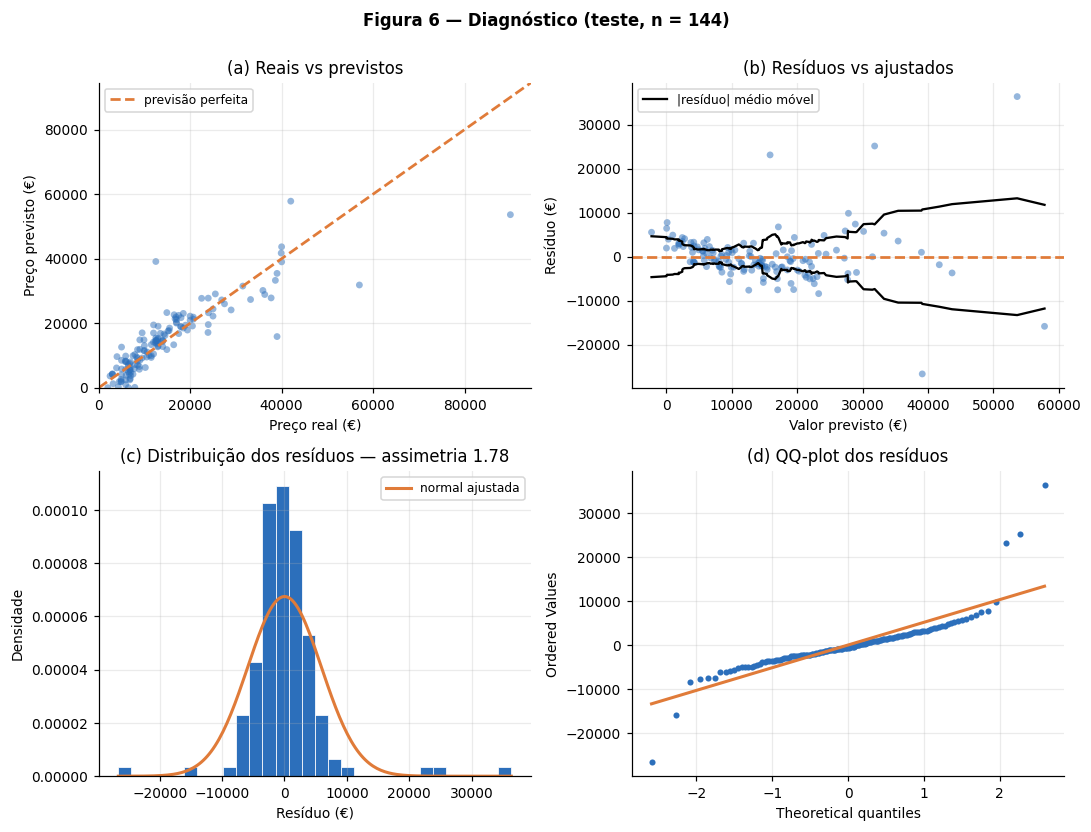

In [24]:
fig, ax = plt.subplots(2, 2, figsize=(10, 7.5))

a = ax[0, 0]
a.scatter(yte, pred, s=20, alpha=0.5, color=AZUL, edgecolors="none")
lim = [0, max(yte.max(), pred.max()) * 1.05]
a.plot(lim, lim, color=LARANJA, lw=1.8, ls="--", label="previsão perfeita")
a.set_xlim(lim); a.set_ylim(lim)
a.set_xlabel("Preço real (€)"); a.set_ylabel("Preço previsto (€)")
a.set_title("(a) Reais vs previstos"); a.legend(fontsize=8)

b = ax[0, 1]
b.scatter(pred, resid, s=20, alpha=0.5, color=AZUL, edgecolors="none")
b.axhline(0, color=LARANJA, lw=1.8, ls="--")
o = np.argsort(pred); jan = max(5, len(pred)//10)
suave = pd.Series(np.abs(resid)[o]).rolling(jan, center=True, min_periods=3).mean()
b.plot(pred[o], suave, color="black", lw=1.5, label="|resíduo| médio móvel")
b.plot(pred[o], -suave, color="black", lw=1.5)
b.set_xlabel("Valor previsto (€)"); b.set_ylabel("Resíduo (€)")
b.set_title("(b) Resíduos vs ajustados"); b.legend(fontsize=8)

c = ax[1, 0]
c.hist(resid, bins=30, color=AZUL, edgecolor="white", linewidth=0.5, density=True)
xx = np.linspace(resid.min(), resid.max(), 200)
c.plot(xx, stats.norm.pdf(xx, resid.mean(), resid.std()), color=LARANJA, lw=2, label="normal ajustada")
c.set_xlabel("Resíduo (€)"); c.set_ylabel("Densidade")
c.set_title(f"(c) Distribuição dos resíduos — assimetria {stats.skew(resid):.2f}")
c.legend(fontsize=8)

dax = ax[1, 1]
stats.probplot(resid, dist="norm", plot=dax)
dax.get_lines()[0].set_markerfacecolor(AZUL); dax.get_lines()[0].set_markeredgecolor("none")
dax.get_lines()[0].set_markersize(4)
dax.get_lines()[1].set_color(LARANJA); dax.get_lines()[1].set_linewidth(2)
dax.set_title("(d) QQ-plot dos resíduos")

fig.suptitle(f"Figura 6 — Diagnóstico (teste, n = {len(yte)})", fontweight="bold", y=1.00)
fig.tight_layout(); plt.show()

In [25]:
print(f"Resíduo médio : {resid.mean():>9,.0f} €   (esperado ~ 0)")
print(f"Assimetria    : {stats.skew(resid):>9.2f}")
print(f"Curtose       : {stats.kurtosis(resid):>9.2f}")

sh = stats.shapiro(resid)
print(f"\nShapiro-Wilk: W = {sh.statistic:.4f}, p = {sh.pvalue:.2e}  -> normalidade REJEITADA")

rho, pv = stats.spearmanr(pred, np.abs(resid))
print(f"Spearman(|resíduo|, ajustado): rho = {rho:.3f}, p = {pv:.2e}  -> HETEROSCEDASTICIDADE")

print(f"\nErro absoluto mediano: {np.median(np.abs(resid)):,.0f} €")
print(f"Erro absoluto médio  : {np.mean(np.abs(resid)):,.0f} €")
print(f"P90 do erro absoluto : {np.percentile(np.abs(resid), 90):,.0f} €")

Resíduo médio :        18 €   (esperado ~ 0)
Assimetria    :      1.78
Curtose       :     14.35

Shapiro-Wilk: W = 0.7588, p = 4.18e-14  -> normalidade REJEITADA
Spearman(|resíduo|, ajustado): rho = 0.221, p = 7.89e-03  -> HETEROSCEDASTICIDADE

Erro absoluto mediano: 2,300 €
Erro absoluto médio  : 3,486 €
P90 do erro absoluto : 6,116 €


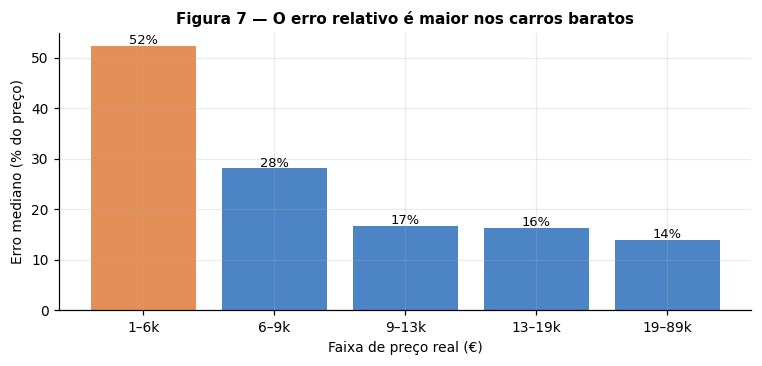

In [26]:
# Erro relativo por faixa de preço
faixas = pd.qcut(yte, 5)
er = pd.DataFrame({"faixa": faixas.values, "pct": 100*np.abs(resid)/yte.values})
g = er.groupby("faixa", observed=True)["pct"].median()

fig, ax = plt.subplots(figsize=(7, 3.4))
rot = [f"{int(i.left/1000)}–{int(i.right/1000)}k" for i in g.index]
cores = [LARANJA if v > 30 else AZUL for v in g.values]
ax.bar(range(len(g)), g.values, color=cores, alpha=0.85)
ax.set_xticks(range(len(g))); ax.set_xticklabels(rot)
ax.set_xlabel("Faixa de preço real (€)"); ax.set_ylabel("Erro mediano (% do preço)")
ax.set_title("Figura 7 — O erro relativo é maior nos carros baratos", fontweight="bold", fontsize=10)
for i, v in enumerate(g.values):
    ax.text(i, v + 0.4, f"{v:.0f}%", ha="center", fontsize=8.5)
fig.tight_layout(); plt.show()

## 7.2 Síntese do diagnóstico

| Pressuposto | Situação | Gravidade |
|---|---|---|
| Linearidade | Adequada até ~30.000 €; subestima acima | Moderada |
| Homoscedasticidade | **Violada** (ρ = 0,22; p = 0,008) | Relevante |
| Normalidade dos resíduos | **Violada** (Shapiro p ≈ 0; curtose 14,4) | Moderada |
| Independência | Não avaliável; risco por concessionária | Baixa a moderada |
| Colinearidade | Aceitável (VIF máx. 2,76) | **Não é problema** |
| Observações influentes | Alta potência e premium antigos | Relevante |

**Achado de maior consequência prática.** Em euros o modelo erra mais nos
carros caros; em percentual, erra muito mais nos baratos — cerca de metade do
preço na faixa mais baixa.

## 7.3 Alternativas para os pressupostos violados

**Heteroscedasticidade:** mínimos quadrados ponderados (WLS), mantendo a escala
em euros; ou log com correção de *smearing* de Duan, que corrige o viés de
retransformação identificado na seção 6.1; ou erros-padrão robustos (HC3).

**Não normalidade:** *bootstrap* dos resíduos para intervalos de predição, que
dispensa a suposição distribucional.

**Subestimação dos caros:** interação `cv` × `marca`, ou tratamento separado do
segmento premium. A base atual não comporta essa complexidade.

---
# 8. Previsões de exemplo e risco de extrapolação

In [27]:
exemplos = [
    ("A. Popular usado típico", dict(idade=6, km=95000, cv=110, puertas=5,
        transmision="manual", combustible="diesel", marca_agrupada="OPEL")),
    ("B. Seminovo automático", dict(idade=2, km=30000, cv=150, puertas=5,
        transmision="automatico", combustible="gasolina", marca_agrupada="VOLKSWAGEN")),
    ("C. EXTRAPOLAÇÃO: 25 anos", dict(idade=25, km=300000, cv=90, puertas=3,
        transmision="manual", combustible="gasolina", marca_agrupada="SEAT")),
]

mae = np.mean(np.abs(resid))
for nome, caso in exemplos:
    v = pf.predict(pd.DataFrame([caso]))[0]
    sim = d_rest[(d_rest.idade.between(caso["idade"]-1, caso["idade"]+1)) &
                 (d_rest.cv.between(caso["cv"]-25, caso["cv"]+25))]
    print(f"\n{nome}")
    print(f"  previsão: {v:>9,.0f} €   (faixa ±MAE: {max(0,v-mae):,.0f} a {v+mae:,.0f} €)")
    if len(sim):
        print(f"  {len(sim)} anúncios similares na base — mediana real: {sim.precio.median():,.0f} €")
    else:
        print("  NENHUM anúncio similar na base  <-- extrapolação")


A. Popular usado típico
  previsão:    10,238 €   (faixa ±MAE: 6,753 a 13,724 €)
  41 anúncios similares na base — mediana real: 9,950 €

B. Seminovo automático
  previsão:    20,943 €   (faixa ±MAE: 17,457 a 24,428 €)
  61 anúncios similares na base — mediana real: 20,690 €

C. EXTRAPOLAÇÃO: 25 anos
  previsão:        56 €   (faixa ±MAE: 0 a 3,542 €)
  NENHUM anúncio similar na base  <-- extrapolação


In [28]:
# Como a previsão varia só com a idade (demais fixos no perfil A)
base_a = dict(km=95000, cv=110, puertas=5, transmision="manual",
              combustible="diesel", marca_agrupada="OPEL")
print("Efeito isolado da idade:\n")
for i in [0, 3, 6, 10, 15, 20]:
    v = pf.predict(pd.DataFrame([{**base_a, "idade": i}]))[0]
    print(f"  {i:>2} anos: {v:>9,.0f} €")

Efeito isolado da idade:

   0 anos:    17,451 €
   3 anos:    13,378 €
   6 anos:    10,238 €
  10 anos:     7,503 €
  15 anos:     6,415 €
  20 anos:     7,920 €


**Interpretação.**

- **Exemplo A**: previsão de 10.238 €; 41 anúncios similares na base têm
  mediana real de 9.950 €. Erro de ~3%.
- **Exemplo B**: previsão de 20.943 €; 61 similares com mediana de 20.690 €.
  Erro de ~1,2%. A diferença de 10.000 € em relação a A vem da **combinação**
  de quatro anos a menos, 65.000 km a menos, 40 cv a mais e câmbio automático.
- **Exemplo C**: previsão de **56 €** — absurda. Não há nenhum anúncio similar
  na base. O modelo está extrapolando para uma região que nunca observou.

A tabela de efeito isolado mostra o problema com clareza: o preço cai
consistentemente até os 15 anos e **volta a subir aos 20**. Não há justificativa
de mercado: é o termo quadrático virando para cima onde os dados rareiam.

**Faixa de validade.** O modelo é confiável entre 0 e ~15 anos. Entre 15 e 20,
com desconfiança. Acima de 20, não deve ser usado — e a aplicação impede a
entrada.

---
# 9. Conclusão

## 9.1 Quais variáveis mais explicam o preço

1. **Potência** (r = 0,617) — ~113 € por cavalo. Proxy de segmento.
2. **Idade** — ~521 € por ano, mas a média esconde o padrão real: a perda é
   muito maior nos primeiros anos.
3. **Quilometragem** — ~472 € a cada 10.000 km.
4. **Câmbio automático** — prêmio de ~1.499 €, demais características constantes.
5. **Marca** — pouco relevante após os controles, exceto MERCEDES-BENZ (+4.990 €).
6. **Portas** — praticamente sem associação (r = −0,014).

## 9.2 As hipóteses se confirmaram?

| Hipótese | Resultado |
|---|---|
| **H1** — Relação idade-preço convexa | **Confirmada** |
| **H2** — `cv` preditor isolado mais forte | **Confirmada** |
| **H3** — Colinearidade problemática | **Parcialmente refutada** (VIF 2,76) |
| **H4** — Automático com confundimento | **Confirmada** (86% era confundimento) |
| **H5** — Antigos fogem da curva | **Confirmada** (6 clássicos) |

## 9.3 Erro típico em dados não usados no treino

| Medida | Valor |
|---|---:|
| Erro absoluto **mediano** | 2.300 € |
| Erro absoluto médio (MAE) | 3.486 € |
| 90% dos erros abaixo de | 6.116 € |
| R² | 0,749 |

Metade das previsões erra menos de 2.300 €. O MAE é maior porque poucos casos
extremos puxam a média. O modelo explica ~75% da variação; o restante
corresponde a fatores ausentes da base.

## 9.4 Quando o modelo é útil

- Estimar preço de anúncio inicial para veículos comuns (até 15 anos,
  6.000 € a 40.000 €).
- Identificar anúncios fora do padrão (diferença > 6.000 € merece investigação).
- Quantificar o valor de características específicas.

## 9.5 Quando não deve ser utilizado

- **Veículos com mais de 20 anos** — fora do domínio; clássicos são
  precificados por raridade.
- **Abaixo de 6.000 €** — erro relativo mediano de ~52%.
- **Acima de 300 cv** — concentram os maiores erros.
- **Marcas premium antigas** — um Mercedes de 14 anos e 163.000 km foi previsto
  em 39.121 € contra 12.490 € reais.
- **Fora do mercado espanhol ou de abril de 2021.**
- **Como avaliação definitiva** — estima preço *pedido*, não de transação.

## 9.6 Limitações dos dados

1. Apenas 500 anúncios originais (484 após tratamento).
2. Coleta em data única — sem variação temporal.
3. 497 de 500 anúncios são de vendedores profissionais.
4. Preço pedido, não negociado.
5. Ausência de estado de conservação, histórico de manutenção, sinistros e
   versão exata do modelo.
6. Documentação da fonte contraditória (data) e incompleta (combustível).

## 9.7 O que melhoraria o modelo

1. **Estado de conservação** — provavelmente a variável ausente mais importante;
   explicaria boa parte do erro de 52% na faixa baixa.
2. **Mais observações** (5.000 a 10.000) — permitiria manter 34 marcas, incluir
   interações e tratar o segmento premium separadamente.
3. **Versão específica do modelo** — um Golf GTI e um Golf básico do mesmo ano
   têm preços muito diferentes.
4. **Coleta em múltiplas datas** — captaria sazonalidade e tendência.
5. **Preço de fechamento** — mudaria de "quanto se pede" para "quanto se paga".
6. **Região do vendedor** — `ubicacion` está na base e não foi utilizada.

## 9.8 Ressalva final sobre causalidade

Todos os resultados descrevem **associações observadas entre anúncios**. O
coeficiente de −521 €/ano não significa que um carro perderá esse valor no
próximo ano; significa que veículos um ano mais velhos e semelhantes nas demais
características são **anunciados** por 521 € a menos, em média.

O desenho é observacional e transversal, sem atribuição aleatória e com
variáveis omitidas relevantes. Nenhuma conclusão causal é sustentada.

---

## Aplicação Streamlit

```bash
python treinar_modelo.py   # gera modelo/modelo.pkl
streamlit run app.py
```

A entrada do usuário passa pelo **mesmo objeto `Pipeline`** ajustado aqui — não
há regra de pré-processamento duplicada entre notebook e aplicação.